In [2]:
# ======================================================================
# 
# Objectif : Réaliser une ACP normée pour étudier 10 boissons de jus
#             et "gagner le maximum d'informations" :
#   - Matrice centrée-réduite
#   - Matrice de corrélation R = (1/n) Z'Z
#   - Valeurs propres / inertie / taux cumulés
#   - Coordonnées des individus (boissons)
#   - Coordonnées des variables (cercle des corrélations)
#   - cos² individus et variables
#   - Contributions individus / variables
#   - Graphiques : histogramme des VP, plan F1-F2, cercle, biplot
#   - Interprétation guidée pour savoir quelles boissons "gagnent"
#     selon : fruité, sucré, goût, piquant, amer, rugosité, odeur,
#             acide, parfumé, suffocant.

# ======================================================================

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Pour une meilleure qualité des figures
plt.rcParams["figure.dpi"] = 120

# ----------------------------------------------------------------------
# 0) Dossier de sortie
# ----------------------------------------------------------------------
os.makedirs("output", exist_ok=True)

# ----------------------------------------------------------------------
# 1) Données : 10 boissons x 10 caractéristiques de dégustation
# ----------------------------------------------------------------------
boissons = [
    "Boisson 1","Boisson 2","Boisson 3","Boisson 4","Boisson 5",
    "Boisson 6","Boisson 7","Boisson 8","Boisson 9","Boisson 10"
]

variables = ["Frut","Suc","Gt","Amr","Piq","Rug","Odr","Acd","Parf","Suff"]

X = np.array([
    [2.29, 2.86, 2.86, 3.29, 3.29, 3.00, 3.14, 4.29, 2.29, 0.54],  # B1
    [1.14, 1.79, 3.86, 3.57, 3.57, 3.00, 3.43, 3.71, 1.43, 0.93],  # B2
    [2.71, 4.14, 1.86, 3.57, 3.14, 2.43, 3.71, 3.57, 3.29, 0.64],  # B3
    [4.14, 4.71, 2.00, 3.07, 2.29, 2.57, 4.00, 3.14, 4.14, 0.00],  # B4
    [1.29, 2.29, 3.86, 4.14, 2.86, 3.17, 4.43, 3.86, 2.14, 1.50],  # B5
    [0.00, 1.86, 4.29, 4.79, 2.71, 3.57, 4.14, 3.86, 1.14, 0.64],  # B6
    [3.86, 4.71, 1.57, 2.57, 2.00, 2.71, 3.43, 4.21, 3.57, 0.50],  # B7
    [0.00, 0.00, 2.86, 3.86, 2.71, 3.00, 4.14, 3.86, 1.14, 0.93],  # B8
    [4.07, 4.14, 2.29, 4.00, 1.43, 3.00, 4.07, 3.57, 3.57, 0.50],  # B9
    [3.71, 3.86, 2.43, 4.07, 1.43, 2.79, 6.10, 3.86, 1.57, 2.21],  # B10
])

df = pd.DataFrame(X, index=boissons, columns=variables)
df.index.name = "Boisson"

print("\n================ (1) MATRICE DES DONNEES ==================\n")
print(df.round(3))


================ (1) MATRICE DES DONNEES ==================

            Frut   Suc    Gt   Amr   Piq   Rug   Odr   Acd  Parf  Suff
Boisson                                                               
Boisson 1   2.29  2.86  2.86  3.29  3.29  3.00  3.14  4.29  2.29  0.54
Boisson 2   1.14  1.79  3.86  3.57  3.57  3.00  3.43  3.71  1.43  0.93
Boisson 3   2.71  4.14  1.86  3.57  3.14  2.43  3.71  3.57  3.29  0.64
Boisson 4   4.14  4.71  2.00  3.07  2.29  2.57  4.00  3.14  4.14  0.00
Boisson 5   1.29  2.29  3.86  4.14  2.86  3.17  4.43  3.86  2.14  1.50
Boisson 6   0.00  1.86  4.29  4.79  2.71  3.57  4.14  3.86  1.14  0.64
Boisson 7   3.86  4.71  1.57  2.57  2.00  2.71  3.43  4.21  3.57  0.50
Boisson 8   0.00  0.00  2.86  3.86  2.71  3.00  4.14  3.86  1.14  0.93
Boisson 9   4.07  4.14  2.29  4.00  1.43  3.00  4.07  3.57  3.57  0.50
Boisson 10  3.71  3.86  2.43  4.07  1.43  2.79  6.10  3.86  1.57  2.21


In [3]:
# ----------------------------------------------------------------------
# 2) ACP NORMEE (données centrées-réduites, matrice de CORRELATION)
# ----------------------------------------------------------------------
n, p = df.shape  # n = 10 boissons, p = 10 variables

# 2.1 Moyennes et écarts-types (avec 1/n pour la variance, comme en cours)
moy = df.mean(axis=0)
std = df.std(axis=0, ddof=0)  # ddof=0 => division par n

print("\n================ (2) MOYENNES DES VARIABLES ===============\n")
print(moy.round(4))
print("\n================ (3) ECARTS-TYPES DES VARIABLES ==========\n")
print(std.round(4))


================ (2) MOYENNES DES VARIABLES ===============

Frut    2.321
Suc     3.036
Gt      2.788
Amr     3.693
Piq     2.543
Rug     2.924
Odr     4.059
Acd     3.793
Parf    2.428
Suff    0.839
dtype: float64

================ (3) ECARTS-TYPES DES VARIABLES ==========

Frut    1.5508
Suc     1.4650
Gt      0.8892
Amr     0.5924
Piq     0.7044
Rug     0.3056
Odr     0.7796
Acd     0.3117
Parf    1.0693
Suff    0.5861
dtype: float64


In [7]:
# 2.2 Matrice centrée-réduite Z
Z = (df - moy) / std

print("\n================ (4) MATRICE CENTREE-REDUITE Z =====================================\n")
print(Z.round(4))


================ (4) MATRICE CENTREE-REDUITE Z =====================================

              Frut     Suc      Gt     Amr     Piq     Rug     Odr     Acd  \
Boisson                                                                      
Boisson 1  -0.0200 -0.1201  0.0810 -0.6803  1.0605  0.2487 -1.1788  1.5944   
Boisson 2  -0.7615 -0.8505  1.2056 -0.2076  1.4580  0.2487 -0.8068 -0.2663   
Boisson 3   0.2508  0.7536 -1.0436 -0.2076  0.8475 -1.6164 -0.4477 -0.7154   
Boisson 4   1.1729  1.1427 -0.8862 -1.0516 -0.3592 -1.1583 -0.0757 -2.0949   
Boisson 5  -0.6648 -0.5092  1.2056  0.7546  0.4500  0.8049  0.4759  0.2149   
Boisson 6  -1.4967 -0.8027  1.6892  1.8518  0.2371  2.1137  0.1039  0.2149   
Boisson 7   0.9924  1.1427 -1.3698 -1.8957 -0.7709 -0.7002 -0.8068  1.3378   
Boisson 8  -1.4967 -2.0724  0.0810  0.2819  0.2371  0.2487  0.1039  0.2149   
Boisson 9   1.1278  0.7536 -0.5601  0.5182 -1.5801  0.2487  0.0141 -0.7154   
Boisson 10  0.8957  0.5625 -0.4026  0.6364 -1.5801 -0.4

In [8]:
# 2.3 Matrice de CORRELATION R = (1/n) Z'Z
R = (Z.T @ Z) / n
R_df = pd.DataFrame(R, index=variables, columns=variables)

print("\n================ (5) MATRICE DE CORRELATION R = (1/n) Z'Z =\n")
print(R_df.round(4))


================ (5) MATRICE DE CORRELATION R = (1/n) Z'Z =

        Frut     Suc      Gt     Amr     Piq     Rug     Odr     Acd    Parf  \
Frut  1.0000  0.9309 -0.8023 -0.5536 -0.6311 -0.6836  0.1370 -0.2539  0.8124   
Suc   0.9309  1.0000 -0.7186 -0.4972 -0.5010 -0.6264  0.0424 -0.2515  0.8420   
Gt   -0.8023 -0.7186  1.0000  0.6954  0.4817  0.8591  0.0267  0.1533 -0.7591   
Amr  -0.5536 -0.4972  0.6954  1.0000 -0.0340  0.7102  0.4926 -0.0827 -0.6324   
Piq  -0.6311 -0.5010  0.4817 -0.0340  1.0000  0.1434 -0.6052  0.1407 -0.3325   
Rug  -0.6836 -0.6264  0.8591  0.7102  0.1434  1.0000  0.0367  0.3385 -0.6614   
Odr   0.1370  0.0424  0.0267  0.4926 -0.6052  0.0367  1.0000 -0.1566 -0.2903   
Acd  -0.2539 -0.2515  0.1533 -0.0827  0.1407  0.3385 -0.1566  1.0000 -0.3971   
Parf  0.8124  0.8420 -0.7591 -0.6324 -0.3325 -0.6614 -0.2903 -0.3971  1.0000   
Suff -0.1477 -0.2367  0.2742  0.4442 -0.1961  0.1583  0.7836  0.2733 -0.5838   

        Suff  
Frut -0.1477  
Suc  -0.2367  
Gt    0.2742

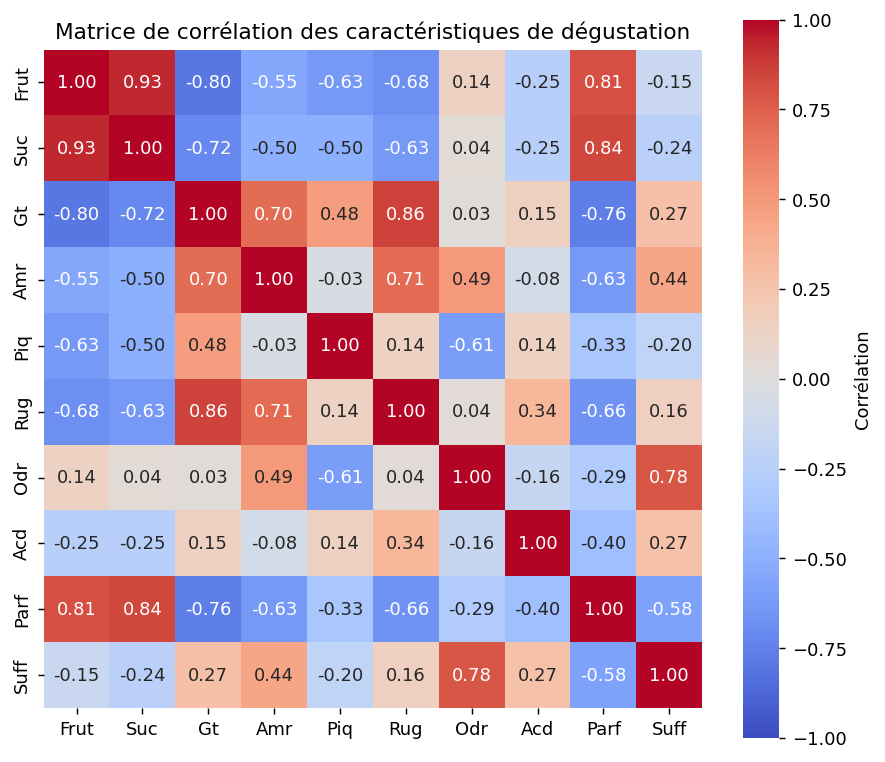

In [19]:
# ======================================================================
# HEATMAP DE LA MATRICE DE CORRELATION R
# ======================================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130

plt.figure(figsize=(7,6))
sns.heatmap(
    R_df,                  # matrice de corrélation (DataFrame)
    annot=True,            # afficher les coefficients
    fmt=".2f",
    cmap="coolwarm",       # bleu = corrélation négative, rouge = positive
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Corrélation"}
)
plt.title("Matrice de corrélation des caractéristiques de dégustation")
plt.tight_layout()
plt.show()

Fruté et sucré sont très liés : corr(Frut, Suc) ≈ 0.93, corr(Suc, Parf) ≈ 0.84, corr(Frut, Parf) ≈ 0.81.
→ Les jus très fruités sont aussi les plus sucrés et parfumés.

Goût fort s’oppose à ce profil agréable : corr(Gt, Frut) ≈ -0.80, corr(Gt, Suc) ≈ -0.72, corr(Gt, Parf) ≈ -0.76, et il est lié à la rugosité corr(Gt, Rug) ≈ 0.86.
→ Quand Gt est élevé, le jus est moins fruité/sucré/parfumé et plus rugueux.

L’amertume suit la même logique : corr(Amr, Parf) ≈ -0.63, corr(Amr, Gt) ≈ 0.70, corr(Amr, Rug) ≈ 0.71.
→ Les jus amers sont aussi au goût fort et rugueux, donc moins agréables.

Odeur forte et caractère suffocant vont ensemble : corr(Odr, Suff) ≈ 0.78, alors que Suff est négativement corrélé à Parf (corr ≈ -0.58).
→ Une odeur très forte est souvent suffocante, contrairement au parfum agréable.

In [10]:
# ----------------------------------------------------------------------
# 3) Décomposition spectrale de R (valeurs propres / vecteurs propres)
# ----------------------------------------------------------------------
valp, vecp = np.linalg.eigh(R)           # R est symétrique
idx = np.argsort(valp)[::-1]             # tri décroissant
valp = valp[idx]
vecp = vecp[:, idx]

# inertie totale = somme des valeurs propres = p (ACP normée)
inertie_totale = valp.sum()
taux = valp / inertie_totale * 100
taux_cum = taux.cumsum()
axes = [f"F{i+1}" for i in range(p)]

axes_df = pd.DataFrame({
    "Axe": axes,
    "Valeur_propre": valp,
    "Taux_inertie_%": taux,
    "Taux_cumule_%": taux_cum
})

print("\n================ (6) VALEURS PROPRES / INERTIE ===========\n")
print(axes_df.round(4))

axes_df.to_csv("output/tableau_valeurs_propres.csv", index=False)

print("\nInterprétation :")
print(f"- Inertie totale = {inertie_totale:.4f} (≈ p = {p} en ACP normée).")
print(f"- F1 explique {taux[0]:.2f}% de l'inertie, F2 {taux[1]:.2f}% ; F1+F2 = {taux_cum[1]:.2f}%.")
print(f"- F1+F2+F3 = {taux_cum[2]:.2f}% ; F1..F6 = {taux_cum[5]:.2f}% environ.")
print("- Critère de Kaiser : on retient les axes de valeur propre > 1.")


================ (6) VALEURS PROPRES / INERTIE ===========

   Axe  Valeur_propre  Taux_inertie_%  Taux_cumule_%
0   F1         5.0347         50.3475        50.3475
1   F2         2.3995         23.9949        74.3424
2   F3         1.1538         11.5377        85.8802
3   F4         0.7738          7.7378        93.6180
4   F5         0.3544          3.5438        97.1618
5   F6         0.1540          1.5396        98.7013
6   F7         0.0674          0.6741        99.3755
7   F8         0.0442          0.4421        99.8175
8   F9         0.0182          0.1825       100.0000
9  F10        -0.0000         -0.0000       100.0000

Interprétation :
- Inertie totale = 10.0000 (≈ p = 10 en ACP normée).
- F1 explique 50.35% de l'inertie, F2 23.99% ; F1+F2 = 74.34%.
- F1+F2+F3 = 85.88% ; F1..F6 = 98.70% environ.
- Critère de Kaiser : on retient les axes de valeur propre > 1.


In [ ]:
# ----------------------------------------------------------------------
# 4) Coordonnées des individus (boissons) sur les axes principaux
#    C = Z * U   (U = matrice des vecteurs propres)
# ----------------------------------------------------------------------
C = Z.values @ vecp
coord_ind_df = pd.DataFrame(C, index=boissons, columns=axes)

print("\n================ (7) COORDONNEES DES BOISSONS ============\n")
print(coord_ind_df.round(4))





================ (7) COORDONNEES DES BOISSONS ============

                F1      F2      F3      F4      F5      F6      F7      F8  \
Boisson 1   0.2840  1.8184  1.4182 -0.4592  0.3644  0.1404 -0.1313  0.1431   
Boisson 2   1.7680  1.4078 -0.1604  0.8839  0.4831 -0.5730 -0.0850  0.3052   
Boisson 3  -1.8559  0.7222 -0.3541  1.2532  0.2909  0.9041  0.0137 -0.0078   
Boisson 4  -3.3776  0.4081 -1.7354  0.3717 -0.0808 -0.4777 -0.1789 -0.2025   
Boisson 5   1.9770 -0.5716 -0.0346  0.0978  0.7320 -0.1364  0.5646 -0.2646   
Boisson 6   3.5189  0.0892 -1.0430 -1.2578  0.0852  0.2720 -0.3649 -0.1823   
Boisson 7  -2.8417  0.7249  1.8087 -0.8495 -0.2276 -0.1899  0.0091 -0.2003   
Boisson 8   2.2555  0.3624  0.2288  0.7586 -1.5510  0.0025  0.1274 -0.0224   
Boisson 9  -1.6829 -0.9446 -1.0496 -1.3557 -0.2500  0.1175  0.2950  0.3744   
Boisson 10 -0.0454 -4.0168  0.9214  0.5571  0.1539 -0.0595 -0.2496  0.0572   

                F9  F10  
Boisson 1   0.2823  0.0  
Boisson 2  -0.1663 -0.0  
Bo

In [20]:

# ----------------------------------------------------------------------
# 5) Qualité de représentation des individus sur F1-F2 (cos²)
# ----------------------------------------------------------------------
dist2_ind = (coord_ind_df**2).sum(axis=1)  # distance² au centre
cos2_ind_F12 = ((coord_ind_df["F1"]**2 + coord_ind_df["F2"]**2)
                / dist2_ind) * 100

qual_ind_df = pd.DataFrame({
    "F1": coord_ind_df["F1"],
    "F2": coord_ind_df["F2"],
    "cos2_F1F2_%": cos2_ind_F12
}, index=boissons)

print("\n===== (8) QUALITE REPRESENTATION BOISSONS SUR F1-F2 (cos² %) =====\n")
print(qual_ind_df.round(4))




===== (8) QUALITE REPRESENTATION BOISSONS SUR F1-F2 (cos² %) =====

                F1      F2  cos2_F1F2_%
Boisson 1   0.2840  1.8184      57.6117
Boisson 2   1.7680  1.4078      77.3374
Boisson 3  -1.8559  0.7222      60.3500
Boisson 4  -3.3776  0.4081      76.9085
Boisson 5   1.9770 -0.5716      81.5798
Boisson 6   3.5189  0.0892      80.9104
Boisson 7  -2.8417  0.7249      67.4013
Boisson 8   2.2555  0.3624      63.0991
Boisson 9  -1.6829 -0.9446      53.4539
Boisson 10 -0.0454 -4.0168      92.7940


Les boissons 10, 5 et 6 sont les mieux représentées sur le plan F1–F2 (cos² > 80%), puis 2 et 4 (≈ 77%), ce qui signifie que leur interprétation se fait principalement sur ce plan, tandis que les boissons 1 et 9, avec des cos² autour de 55%, sont un peu moins bien décrites et demandent éventuellement de considérer les axes suivants. 

In [21]:
# contributions absolues des individus à F1 et F2
contrib_ind_F1 = (coord_ind_df["F1"]**2 / (n * valp[0])) * 100
contrib_ind_F2 = (coord_ind_df["F2"]**2 / (n * valp[1])) * 100

contrib_ind_df = pd.DataFrame({
    "ctr_F1_%": contrib_ind_F1,
    "ctr_F2_%": contrib_ind_F2
}, index=boissons)

print("\n===== (9) CONTRIBUTIONS DES BOISSONS AUX AXES F1 ET F2 (%) =======\n")
print(contrib_ind_df.round(4))


===== (9) CONTRIBUTIONS DES BOISSONS AUX AXES F1 ET F2 (%) =======

            ctr_F1_%  ctr_F2_%
Boisson 1     0.1602   13.7802
Boisson 2     6.2088    8.2591
Boisson 3     6.8409    2.1740
Boisson 4    22.6591    0.6941
Boisson 5     7.7631    1.3615
Boisson 6    24.5943    0.0332
Boisson 7    16.0395    2.1897
Boisson 8    10.1047    0.5474
Boisson 9     5.6252    3.7187
Boisson 10    0.0041   67.2420


L’axe F1 est surtout construit par les boissons 6 et 4, puis 7 et 8, ce sont elles qui portent l’opposition principale sur cet axe
L’axe F2 est pratiquement porté par la boisson 10, plus de 67% de contribution, avec un rôle secondaire des boissons 1 et 2, les autres ayant un poids négligeable.

In [22]:
# ----------------------------------------------------------------------
# 6) Coordonnées des variables (cercle des corrélations)
#    Pour des données centrées-réduites :
#      coordonnée variable j sur l'axe k = corr(X_j, C_k)
#    Mathématiquement : φ = V * sqrt(λ)  (V = vecteurs propres)
# ----------------------------------------------------------------------
phi = vecp * np.sqrt(np.clip(valp, 0, None))
coord_var_df = pd.DataFrame(phi, index=variables, columns=axes)

print("\n===== (10) COORDONNEES DES VARIABLES DANS LE PLAN F1-F2 =====\n")
print(coord_var_df[["F1","F2"]].round(4))


# cos² des variables sur chaque axe (qualité de représentation)
cos2_var_df = coord_var_df**2

print("\n===== (11) COS² DES VARIABLES SUR F1 ET F2 ==================\n")
print(cos2_var_df[["F1","F2"]].round(4))





===== (10) COORDONNEES DES VARIABLES DANS LE PLAN F1-F2 =====

          F1      F2
Frut -0.9134 -0.3027
Suc  -0.8843 -0.1988
Gt    0.9113  0.0887
Amr   0.7357 -0.4320
Piq   0.4323  0.7474
Rug   0.8291 -0.0000
Odr   0.1344 -0.9666
Acd   0.3318  0.1233
Parf -0.9303  0.1475
Suff  0.4230 -0.7376

===== (11) COS² DES VARIABLES SUR F1 ET F2 ==================

          F1      F2
Frut  0.8343  0.0916
Suc   0.7820  0.0395
Gt    0.8305  0.0079
Amr   0.5412  0.1866
Piq   0.1869  0.5585
Rug   0.6874  0.0000
Odr   0.0181  0.9343
Acd   0.1101  0.0152
Parf  0.8654  0.0218
Suff  0.1789  0.5440


F1 résume essentiellement les variables Frut, Suc, Parf, mais aussi Gt, Rug et Amr (cos² > 0.5)
F2 représente très bien Odr, Piq et Suff (cos² ≈ 0.93, 0.56, 0.54)
Acd : cos²(F1) ≈ 0.11, cos²(F2) ≈ 0.02 → très faible sur ce plan.
→ L’acidité est peu corrélée à F1 et F2 ; il faudrait regarder des axes suivants (F3, F4) pour bien l’étudie

In [23]:
# contributions des variables aux axes
contrib_var_F1 = (coord_var_df["F1"]**2 / valp[0]) * 100
contrib_var_F2 = (coord_var_df["F2"]**2 / valp[1]) * 100

contrib_var_df = pd.DataFrame({
    "ctr_F1_%": contrib_var_F1,
    "ctr_F2_%": contrib_var_F2
}, index=variables)

print("\n===== (12) CONTRIBUTIONS DES VARIABLES AUX AXES F1 ET F2 (%) ====\n")
print(contrib_var_df.round(4))


===== (12) CONTRIBUTIONS DES VARIABLES AUX AXES F1 ET F2 (%) ====

      ctr_F1_%  ctr_F2_%
Frut   16.5703    3.8175
Suc    15.5329    1.6473
Gt     16.4951    0.3276
Amr    10.7492    7.7786
Piq     3.7113   23.2777
Rug    13.6536    0.0000
Odr     0.3589   38.9380
Acd     2.1862    0.6331
Parf   17.1894    0.9071
Suff    3.5531   22.6731


L’axe F1 est principalement construit par Parf, Frut, Suc d’un côté et Gt, Rug, Amr de l’autre : il oppose donc un profil plaisant (fruité, sucré, parfumé) à un profil goût fort, rugueux et amer.

 L’axe F2 est dominé par Odr, Piq et Suff (plus de 80% de contribution à eux trois), avec un rôle secondaire d’Amr : il traduit donc surtout l’intensité d’odeur, le caractère piquant et suf­focant des jus.
 

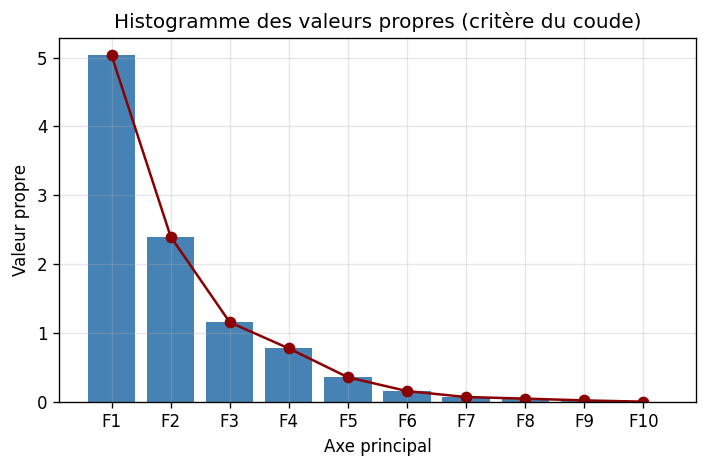

In [14]:
# ----------------------------------------------------------------------
# 7) Graphiques : histogramme des valeurs propres, plan individus,
#    cercle des corrélations, biplot
# ----------------------------------------------------------------------

# 7.1 Histogramme des valeurs propres (critère du coude)
plt.figure(figsize=(6,4))
plt.bar(range(1, p+1), valp, color="steelblue")
plt.plot(range(1, p+1), valp, marker="o", color="darkred")
plt.xticks(range(1, p+1), axes)
plt.xlabel("Axe principal")
plt.ylabel("Valeur propre")
plt.title("Histogramme des valeurs propres (critère du coude)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/histogramme_valeurs_propres.png")
plt.show()

L’histogramme des valeurs propres montre une très grande valeur pour F1, puis une valeur encore importante pour F2 et un coude marqué après F2–F3. Selon le critère du coude et le critère de Kaiser, on retient surtout F1 et F2 pour la représentation : ils expliquent ensemble environ 74% de l’inertie totale, ce qui est suffisant pour décrire les grandes oppositions entre boissons

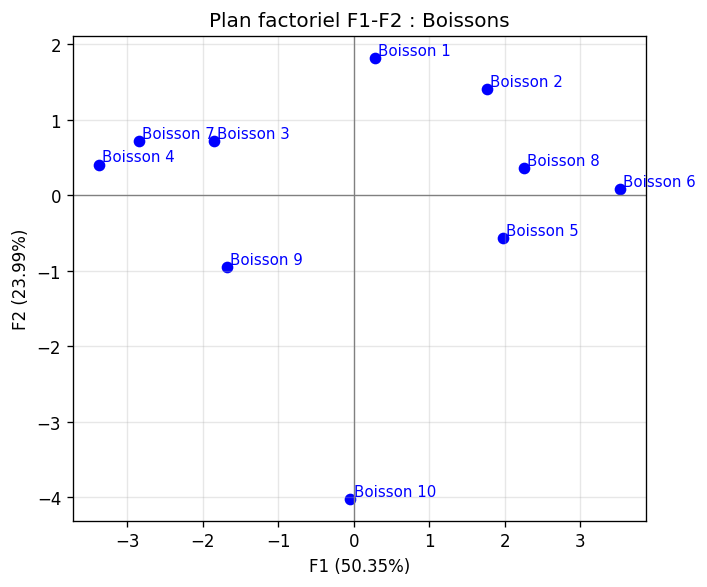

In [27]:

# 7.2 Plan factoriel F1-F2 : individus (boissons)
plt.figure(figsize=(6,5))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.scatter(coord_ind_df["F1"], coord_ind_df["F2"], color="blue")

for b in boissons:
    x = coord_ind_df.loc[b, "F1"]
    y = coord_ind_df.loc[b, "F2"]
    plt.text(x + 0.04, y + 0.04, b, fontsize=9, color="blue")

plt.xlabel(f"F1 ({taux[0]:.2f}%)")
plt.ylabel(f"F2 ({taux[1]:.2f}%)")
plt.title("Plan factoriel F1-F2 : Boissons")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/plan_factoriel_individus.png")
plt.show()



Sur l’axe F2 (piquant / odeur / suffocant)
En haut (F2 > 0) :

Boisson 1 et 2 sont bien au-dessus de l’origine, alignées avec Piq.
→ Ce sont les plus piquantes, plus “agressives” en bouche.

En bas (F2 < 0) :

Boisson 10 est très bas, proche de Odr et Suff, Boisson 9 aussi mais moins extrême.
→ Ces jus se caractérisent par une odeur forte et un côté suffocant plus marqué que les autres

Sur l’axe F1 (profil agréable vs goût fort)
À droite (F1 > 0) :

Boisson 6, 8 et 5 sont clairement du côté positif de F1.
→ Ce sont les jus au profil le plus agréable : plus fruités, sucrés et parfumés, proches des vecteurs Frut, Suc, Parf.

À gauche (F1 < 0) :

Boisson 4, 7, 3, 9 sont du côté négatif de F1.
→ Elles sont relativement moins agréables : profil plus marqué par le goût fort, l’amertume et la rugosité (Gt, Amr, Rug).



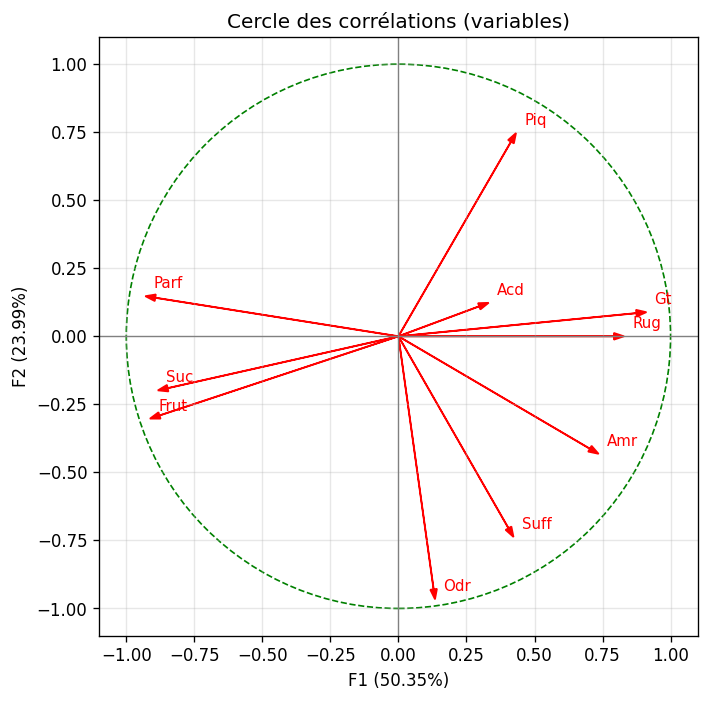

In [26]:

# 7.3 Cercle des corrélations
plt.figure(figsize=(6,6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

# cercle unité
circle = plt.Circle((0,0), 1, color="green", fill=False, linestyle="--")
plt.gca().add_artist(circle)

for v in variables:
    x = coord_var_df.loc[v, "F1"]
    y = coord_var_df.loc[v, "F2"]
    plt.arrow(0, 0, x, y, color="red", head_width=0.025, length_includes_head=True)
    plt.text(x + 0.03, y + 0.03, v, fontsize=9, color="red")

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel(f"F1 ({taux[0]:.2f}%)")
plt.ylabel(f"F2 ({taux[1]:.2f}%)")
plt.title("Cercle des corrélations (variables)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("output/cercle_correlations.png")
plt.show()


Le premier axe F1 traduit surtout un contraste de goût (profil agréable fruité–sucré–parfumé versus goût fort, rugueux et amer), 

alors que le deuxième axe F2 est principalement un axe d’odeur et de gêne respiratoire, construit par Odr, Suff et Piq.

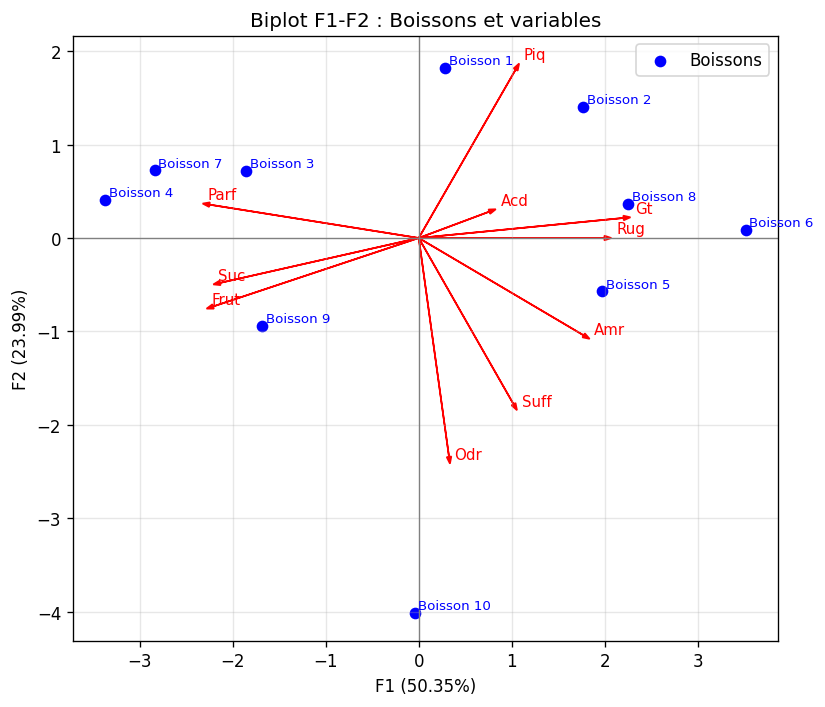

In [25]:
# 7.4 Biplot : individus + variables
plt.figure(figsize=(7,6))
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

# individus
plt.scatter(coord_ind_df["F1"], coord_ind_df["F2"], color="blue", label="Boissons")
for b in boissons:
    x = coord_ind_df.loc[b, "F1"]
    y = coord_ind_df.loc[b, "F2"]
    plt.text(x + 0.04, y + 0.04, b, fontsize=8, color="blue")

# variables (on multiplie par un facteur pour mieux voir dans le même plan)
scale = 2.5
for v in variables:
    x = coord_var_df.loc[v, "F1"] * scale
    y = coord_var_df.loc[v, "F2"] * scale
    plt.arrow(0, 0, x, y, color="red", head_width=0.05, length_includes_head=True)
    plt.text(x + 0.05, y + 0.05, v, fontsize=9, color="red")

plt.xlabel(f"F1 ({taux[0]:.2f}%)")
plt.ylabel(f"F2 ({taux[1]:.2f}%)")
plt.title("Biplot F1-F2 : Boissons et variables")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("output/biplot_boissons_variables.png")
plt.show()


Boisson la mieux notée (brute) par critère :
- Frut : Boisson 4
- Suc : Boisson 4
- Gt : Boisson 6
- Amr : Boisson 6
- Piq : Boisson 2
- Rug : Boisson 6
- Odr : Boisson 10
- Acd : Boisson 1
- Parf : Boisson 4
- Suff : Boisson 10

Sur le plan F1-F2 :
- Les 3 boissons avec le profil le plus 'agréable' (fruité/sucré/parfumé) selon F1 : Boisson 6, Boisson 8, Boisson 5.
- Les 3 boissons les plus 'piquantes/rugueuses' selon F2 : Boisson 1, Boisson 2, Boisson 7.

Le premier axe F1 explique à lui seul environ 50% de l’inertie totale.
Il est construit principalement par les variables Parf, Frut, Suc d’un côté, et Gt, Rug, Amr de l’autre, qui ont les plus fortes contributions à F1 (chacune entre 10% et 17%).

Concrètement, F1 oppose donc un profil agréable, caractérisé par des jus fruités, sucrés et parfumés, à un profil plus “dur”, caractérisé par un goût fort, une rugosité élevée et de l’amertume.

Les boissons situées à droite de l’axe (comme Boisson 6, 8 et 5) ont des coordonnées F1 positives et représentent les jus les plus agréables, alors que celles situées à gauche (Boisson 4, 7, 3, 9) sont plus associées au goût fort, à l’amertume et à la rugosité.

===

Axe F1 :
- Variables les plus contributives :
  * Parf (contribution ≈ 17.19%)
  * Frut (contribution ≈ 16.57%)
  * Gt (contribution ≈ 16.50%)
  * Suc (contribution ≈ 15.53%)
  * Rug (contribution ≈ 13.65%)
- F1 est donc un axe 'plaisir' : il oppose les boissons fruitées/sucrées/parfumées
  (Frut, Suc, Parf, Odr) aux boissons plus amères ou au goût plus lourd (Amr, Gt


Il est dominé par les variables Odr, Piq et Suff, qui contribuent ensemble à plus de 80% de l’inertie de F2

F2 traduit donc essentiellement une dimension “odeur/puissance” : en haut de l’axe, on trouve les jus les plus piquants, proches de la variable Piq (comme Boisson 1 et 2), et en bas les jus à odeur très forte et suffocants, proches de Odr et Suff (notamment Boisson 10, plus Boisson 9).

Les autres boissons, proches de F2 ≈ 0, ne sont ni particulièrement piquantes ni particulièrement suffocantes; leur profil se lit surtout sur F1

Axe F2 :
- Variables les plus contributives :
  * Odr (contribution ≈ 38.94%)
  * Piq (contribution ≈ 23.28%)
  * Suff (contribution ≈ 22.67%)
  * Amr (contribution ≈ 7.78%)
  * Frut (contribution ≈ 3.82%)
- F2 traduit surtout un contraste entre Rugosité/Piquant et Suffocant.
  Les boissons en haut du plan F1-F2 sont plutôt piquantes/rugueuses,
  alors que celles en bas sont plus liées au caractère suffocant.